#  Run of Model **$X$** on the App **MASSA**
 
**Paramaters**
The parameters of all models should be available in the parent folder, in an EXCEL file.

### Imports

In [1]:
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch

from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo import register_dataset

### Adding our Dataset | Metrics | Models

In [2]:
from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)
from neuralhydrology.utils.config import Config

# Custom functions plot_training_curves
from custom.functions.Plot import plot_hydrograph, plot_training_curves, plot_validation_metrics
from custom.functions.utils_fla import parse_neuralhydrology_log


---

### Run parameters

In [3]:
configPath = Path("mape_9.yml")

runFile = "RS_3010_091228"

cfg = Config(configPath)
TRAIN = False
Evaluation_TEST =  True


---
## **Training**

In [4]:
import pandas as pd
csv_path = r"..\..\data\massa_with_RS.csv"
data = pd.read_csv(csv_path)


In [5]:
if TRAIN:
    print("--- Starting the training of the model ---")
    # by default we assume that you have at least one cuda-capable nvidia gpu or macos with metal support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        start_run(config_file=Path(configPath))
    # fall back to cpu-only mode
    else:
        print("Using CPU")
        start_run(config_file=Path(configPath), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")

 Training step skipped !


### Plot of the Loss and Metrics

✅ Parsed 41 training epochs and 41 validation evaluations.
Plotting the losses and metrics throughout the training process: 


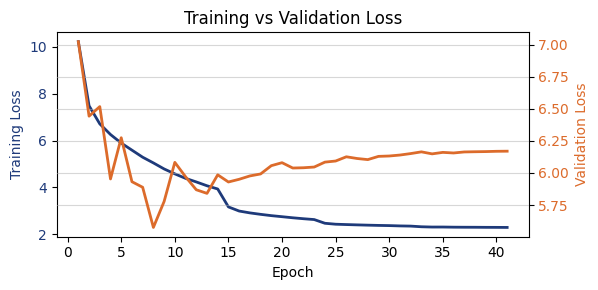

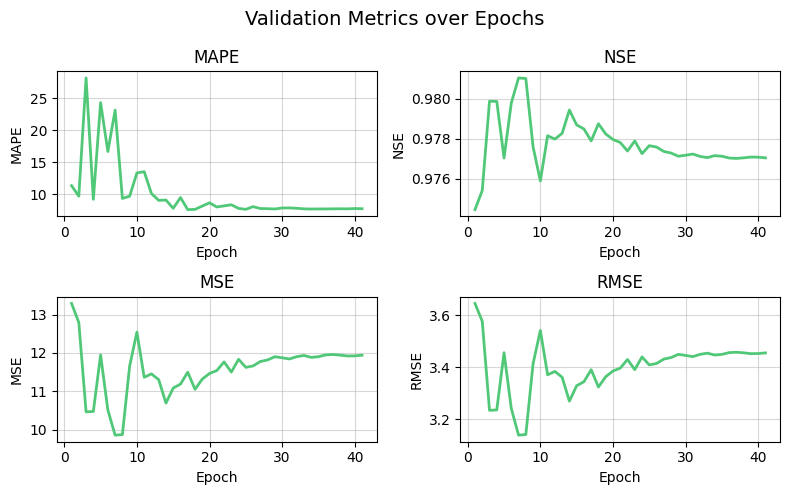

In [6]:
# Path to your output.log file
log_path = Path(f"{cfg.base_run_dir}/{runFile}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path)

print("Plotting the losses and metrics throughout the training process: ")
plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

## Evaluation on the **TEST** Dataset
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [7]:
run_dir = Path(f"{cfg.base_run_dir}/{runFile}")

if Evaluation_TEST:
    print(" Starting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test", from_best=True)
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

 Starting the EVALUATION on the test period:  
  TEST ended successfully !   


---

### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. 

In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

NOTE: The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [8]:
# model_str = f"model_epoch{str(cfg.epochs).zfill(3)}"
model_str = f"model_epoch040"
testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)
basin = "massa_with_RS"
# results.keys()
results[basin]['1h']

{'xr': <xarray.Dataset> Size: 2MB
 Dimensions:         (date: 8785, time_step: 24)
 Coordinates:
   * date            (date) datetime64[ns] 70kB 2023-02-03T23:00:00 ... 2024-0...
   * time_step       (time_step) int64 192B -23 -22 -21 -20 -19 ... -4 -3 -2 -1 0
 Data variables:
     streamflow_obs  (date, time_step) float32 843kB 0.403 0.403 ... 0.603 0.601
     streamflow_sim  (date, time_step) float32 843kB 0.4013 0.4306 ... 0.6076,
 'MAPE': 8.881891250610352,
 'NSE': 0.9719008207321167,
 'MSE': 16.164953231811523,
 'RMSE': 4.020566282479562}

### Plotting model predictions vs observations

Code for 1h prediction:

In [9]:
# qobs=results['massa']['1h']['xr']['streamflow_obs']
# qsim=results['massa']['1h']['xr']['streamflow_sim']
# plot_hydrograph(
#     qobs=qobs,
#     qsim=qsim,
#     results=results,
#     basin='massa',
#     freq='1h',
#     plot_peaks=False  # turn on high-flow markers
# )

Code for 24h predictions:

In [10]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key
from custom.functions.Plot import plot_mape_horizon

results_ = results[basin]["1h"]["xr"]
scores = dict_without_xr_key(results[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']#.values
y_pred = results_['streamflow_sim']#.values

verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)



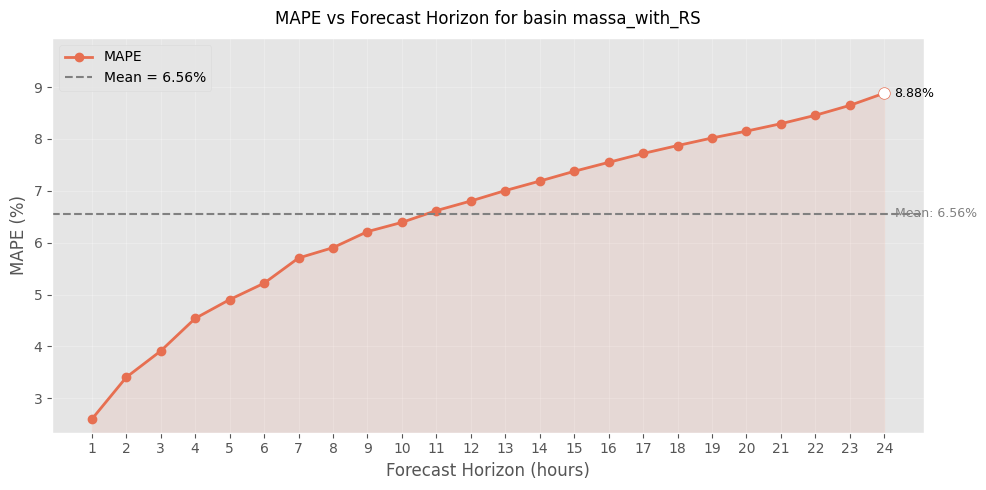

In [11]:
# Example usage (variables `mapes`, `horizons`, and `basin` exist in the notebook):
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


In [12]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])


In [13]:
# Example: visualize forecast issued on April 10, 2024, at midnight
plot_forecast_horizon_24h(
    issue_date="2023-08-10 00:00:00",
    xr_ds=results_
).show()
plot_forecast_horizon_24h(
    issue_date="2023-08-10 01:00:00",
    xr_ds=results_
).show()

In [14]:
plot_forecast_horizon_series(
    issue_date="2023-06-10 00:00:00",
    xr_ds=results_,
    n_forecasts=6
).show()
# 2024-02-04

---

## Computation of all metric scores
Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [15]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.972
MSE: 16.165
RMSE: 4.021
KGE: 0.969
Alpha-NSE: 0.974
Beta-KGE: 0.990
Beta-NSE: -0.008
Pearson-r: 0.986
FHV: -6.878
FMS: 0.185
FLV: 6.598
Peak-Timing: nan
Peak-MAPE: 15.098
MAPE: 8.882


In [16]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.988
MSE: 7.134
RMSE: 2.671
KGE: 0.980
Alpha-NSE: 0.983
Beta-KGE: 0.993
Beta-NSE: -0.006
Pearson-r: 0.994
FHV: -3.823
FMS: -1.201
FLV: 6.565
Peak-Timing: nan
Peak-MAPE: 9.472
MAPE: 5.704
